İlk olarak gerekli kütüphaneleri/modülleri projemize eklememiz gerekiyor. Aşağıdaki kod bloğu gerekli modülleri projemize dahil edecektir.

In [ ]:
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn

 Wisconsin Breast Cancer veri seti, scikit-learn kütüphanesi içinde hazır olarak bulunduğu için işimizi kolaylaştırmak adına veri setini buradan kullanabiliriz.

In [10]:
import os
os.environ["OMP_NUM_THREADS"] = "3"
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
import seaborn as sns

# Veri Setini yükleyelim (sci-kit-learn kütüphanesinde aynı veri setinin bir kopyası bulunuyor.)
cancer_data = load_breast_cancer()

# Veri setinin içeriğini daha kolay anlamak için bir DataFrame oluşturalım.
# Özellikler (features) cancer_data.data içinde, sütun isimleri ise cancer_data.feature_names içinde yer alıyor.
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)

# Gerçek etiketleri (iyi huylu/kötü huylu) de DataFrame'e ekleyelim.
# Bu etiketleri kümeleme sırasında kullanmayacağız ama en son değerlendirme yapmak için ihtiyacımız olacak.
df['target'] = cancer_data.target

print("Veri Setinin İlk 5 Satırı:")
print(df.head())

print("\nVeri Seti Hakkında Bilgiler:")
df.info()

Veri Setinin İlk 5 Satırı:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  w

#### ADIM 1: VERİ HAZIRLIĞI

1.1. Sınıf Etiketlerini Ayırma
- Kümeleme denetimsiz öğrenme olduğu için `target` sınıf etiketlerini ayırmamız gerekiyor. 
- Kümeleme algoritması sadece özellik verisini ('X') görecek.
- 'y' değişkenini ise en sonda, modelin ne kadar başarılı olduğunu ölçmek için saklıyoruz.

In [11]:
X = df.drop('target', axis=1)

y = df['target']

1.2. Veriyi Ölçeklendirme (Scaling)
- **K-Means ve DBSCAN** gibi mesafe tabanlı algoritmalar için bu adım kritiktir.
- Ölçeklendirilmiş verinin başarılı olduğunu görmek için ilk 5 satırını kontrol edelim.

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Ölçeklendirilmiş Özelliklerin İlk 5 Satırı:")
print(X_scaled[:5])

Ölçeklendirilmiş Özelliklerin İlk 5 Satırı:
[[ 1.09706398e+00 -2.07333501e+00  1.26993369e+00  9.84374905e-01
   1.56846633e+00  3.28351467e+00  2.65287398e+00  2.53247522e+00
   2.21751501e+00  2.25574689e+00  2.48973393e+00 -5.65265059e-01
   2.83303087e+00  2.48757756e+00 -2.14001647e-01  1.31686157e+00
   7.24026158e-01  6.60819941e-01  1.14875667e+00  9.07083081e-01
   1.88668963e+00 -1.35929347e+00  2.30360062e+00  2.00123749e+00
   1.30768627e+00  2.61666502e+00  2.10952635e+00  2.29607613e+00
   2.75062224e+00  1.93701461e+00]
 [ 1.82982061e+00 -3.53632408e-01  1.68595471e+00  1.90870825e+00
  -8.26962447e-01 -4.87071673e-01 -2.38458552e-02  5.48144156e-01
   1.39236330e-03 -8.68652457e-01  4.99254601e-01 -8.76243603e-01
   2.63326966e-01  7.42401948e-01 -6.05350847e-01 -6.92926270e-01
  -4.40780058e-01  2.60162067e-01 -8.05450380e-01 -9.94437403e-02
   1.80592744e+00 -3.69203222e-01  1.53512599e+00  1.89048899e+00
  -3.75611957e-01 -4.30444219e-01 -1.46748968e-01  1.08708430e+

Bu işlem sayesinde artık mean area gibi devasa sayılarla mean smoothness gibi çok küçük sayılar arasında bir fark kalmadı. Hepsi aynı "dilde" konuşuyor ve K-Means algoritması için eşit derecede öneme sahipler.

#### Adım 2: Küme Sayısı Belirleme (Elbow Yöntemi)

K-Means algoritmasının en büyük zorluğu, ondan kaç tane küme bulmasını isteyeceğimizi (yani "K" değerini) bizim önceden belirlememiz gerekmesidir. Bunu başarabilmek için kullanacağımız teknik: `Elbow Yöntemi`

1. Modeli **K=1, K=2, K=3, ... K=10** için sırayla çalıştırırız.

2. Her bir K değeri için, modelin "hata payını" (teknik olarak inertia veya WCSS denir) hesaplarız. Bu hata, noktaların kendi küme merkezlerine ne kadar uzak olduğunun bir ölçüsüdür. Kümeler ne kadar sıkıysa, hata o kadar düşük olur.

3. Bu sonuçları bir grafiğe dökeriz. Grafikte hatanın düşüş hızının yavaşladığı, bir "dirseğe" benzeyen kırılma noktası, bizim için en ideal K sayısını gösterir.

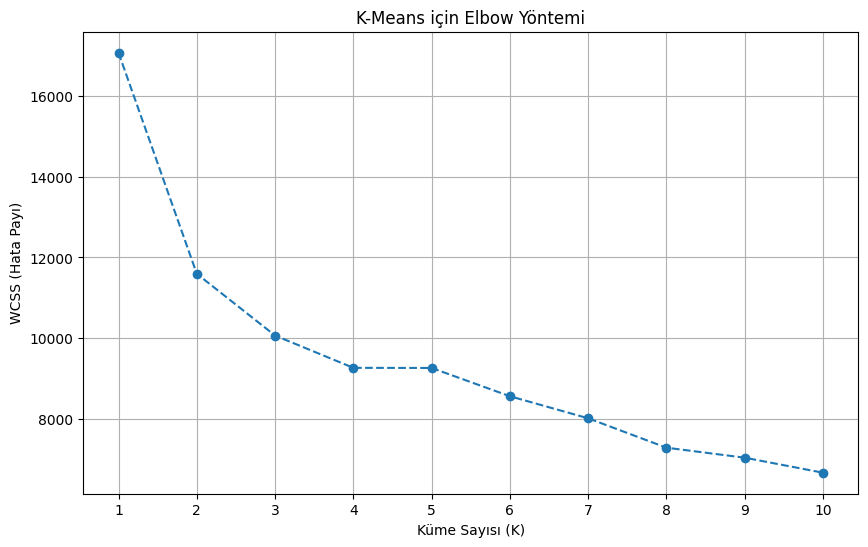

In [13]:
from sklearn.cluster import KMeans

# Farklı K değerleri için WCSS (Within-Cluster Sum of Squares) değerlerini saklamak için bir liste oluşturalım.
wcss = []
k_values = range(1, 11)

for k in k_values:
    # KMeans modelini o anki 'k' değeri ile kuralım
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    # Modeli ölçeklendirilmiş veri üzerinde eğitelim
    kmeans.fit(X_scaled)
    # Modelin wcss (inertia) değerini listeye ekleyelim
    wcss.append(kmeans.inertia_)

# Sonuçları görselleştirelim
plt.figure(figsize=(10, 6))
plt.plot(k_values, wcss, marker='o', linestyle='--')
plt.title('K-Means için Elbow Yöntemi')
plt.xlabel('Küme Sayısı (K)')
plt.ylabel('WCSS (Hata Payı)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

Bu grafiğe göre en belirgin dirsek K=2 noktasında bulunuyor. İkinci bir potansiyel dirsek ise K=3 olarak düşünülebilir.

Bu nedenle, Elbow Yöntemi bize bu veri seti için en uygun küme sayısının 2 veya 3 olabileceğini öneriyor. **Genellikle en keskin kırılma noktası tercih edilir, bu yüzden `K=2` ile devam etmek çok mantıklı bir seçim olacaktır.**

#### Adım 3: Küme Sayısı Belirleme (Silhouette Skoru)

Bu adımda, Elbow yöntemiyle bulduğumuz K=2 sonucunu, Silhouette Skoru ile teyit edeceğiz. Silhouette skoru, kümelerin ne kadar iyi ayrıştığını ölçer ve en yüksek skoru veren K değeri en iyi olarak kabul edilir.

K=2 için Silhouette Skoru: 0.3447
K=3 için Silhouette Skoru: 0.3152
K=4 için Silhouette Skoru: 0.2742


K=5 için Silhouette Skoru: 0.1645
K=6 için Silhouette Skoru: 0.1451
K=7 için Silhouette Skoru: 0.1470
K=8 için Silhouette Skoru: 0.1619
K=9 için Silhouette Skoru: 0.1439
K=10 için Silhouette Skoru: 0.1471


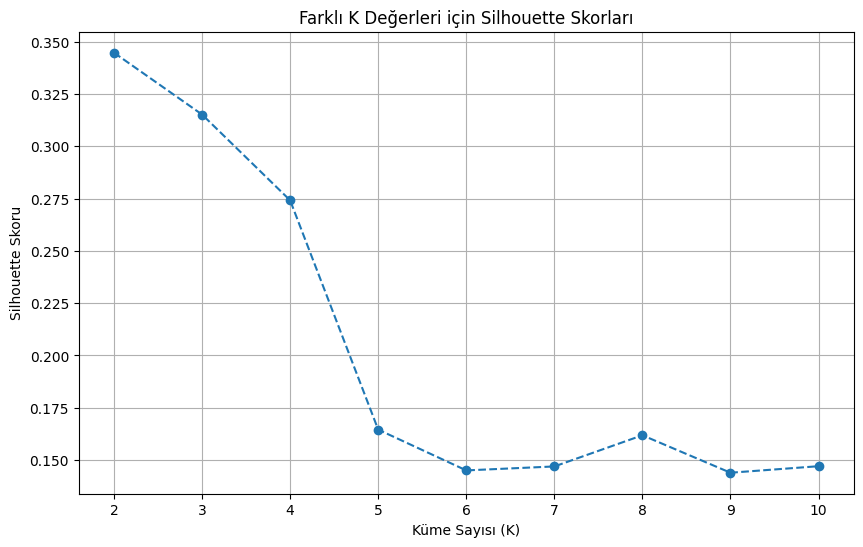

In [14]:
from sklearn.metrics import silhouette_score

# Farklı K değerleri için Silhouette skorlarını saklamak için bir liste
silhouette_scores = []
# Silhouette skoru 1 küme için hesaplanamaz, bu yüzden 2'den başlıyoruz.
k_values = range(2, 11)

for k in k_values:
    # KMeans modelini kuralım
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    
    # Modeli eğitip hangi noktanın hangi kümede olduğunu tahmin edelim
    labels = kmeans.fit_predict(X_scaled)
    
    # O anki k değeri için silhouette skorunu hesaplayalım
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    
    print(f"K={k} için Silhouette Skoru: {score:.4f}")

# Skorları görselleştirelim
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='--')
plt.title('Farklı K Değerleri için Silhouette Skorları')
plt.xlabel('Küme Sayısı (K)')
plt.ylabel('Silhouette Skoru')
plt.xticks(k_values)
plt.grid(True)
plt.show()

Grafiği incelediğimizde, en yüksek Silhouette skorunun açık bir şekilde `K=2` olduğunda elde edildiğini görüyoruz (yaklaşık 0.34 değeriyle). K sayısı arttıkça skorun ne kadar keskin bir şekilde düştüğü de çok net görülüyor.

Bu sonuç, bir önceki adımda Elbow Yöntemi ile yaptığımız tahmini mükemmel bir şekilde doğruluyor. Her iki yöntem de bu veri seti için **en uygun küme sayısının 2 olduğunu işaret ediyor.**

##### Adım 4: Algoritmaların Uygulanması ve Değerlendirilmesi

Önceki adımlarda belirlediğimiz optimal küme sayısı (K=2) ve hazırladığımız ölçeklenmiş veri seti (`X_scaled`) ile şimdi kümeleme algoritmalarını uygulayıp sonuçlarını analiz edeceğiz.

#### Adım 4.1: K-Means Algoritması

Önceki adımlarda en uygun küme sayısını **K=2** olarak belirlemiştik. Şimdi bu parametreyi kullanarak K-Means modelini kuracak ve ölçeklendirilmiş veri setimize uygulayacağız.

In [15]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42)
kmeans.fit(X_scaled)

labels = kmeans.labels_  # KMeans'in oluşturduğu küme etiketleri

y → gerçek sınıflar (0 = kötü huylu, 1 = iyi huylu)

kmeans.labels_ → modelin tahmin ettiği kümeler
Gerçek etiket (y) ile modelin bulduğu kümeleri yan yana görelim

In [16]:
comparison_df = pd.DataFrame({'Gerçek_Sınıf': y, 'Kume': labels})
print(comparison_df.head())

   Gerçek_Sınıf  Kume
0             0     0
1             0     0
2             0     0
3             0     0
4             0     0


Modelin oluşturduğu kümelerin (`labels`) ne kadar başarılı olduğunu anlamak için, en başta ayırdığımız gerçek etiketlerle (`y`) karşılaştıracağız. Bunun için en iyi yöntemlerden biri **Karışıklık Matrisi (Confusion Matrix)** oluşturmaktır.

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, labels)
print("Karışıklık Matrisi:")
print(cm)

Karışıklık Matrisi:
[[175  37]
 [ 13 344]]


Karışıklık Matrisi (Confusion Matrix): Bu, modelin performansını yorumlamak için en kritik çıktılardan biri. `[[175 37], [13 344]]` matrisini şöyle yorumlayabiliriz:

Model, gerçekte kötü huylu (Sınıf 0) olan 212 hastanın 175'ini doğru bir kümeye (Küme 0), 37'sini ise yanlış kümeye atamış.

Gerçekte iyi huylu (Sınıf 1) olan 357 hastanın ise 344'ünü doğru kümeye (Küme 1), 13'ünü ise yanlış kümeye atamış.

<br>

K-Means etiketi 0’ı “kötü huylu” yerine “iyi huylu” olarak atamış olabilir
doğruluğunu ortalamalarına bakarak kontrol edebiliriz

Küme 0’ın ortalaması düşükse → o genelde kötü huylu (0)
Küme 1’in ortalaması yüksekse → iyi huylu (1)

In [18]:
df_with_labels = df.copy()
df_with_labels['Kume'] = labels
print(df_with_labels.groupby('Kume')['target'].mean())

Kume
0    0.069149
1    0.902887
Name: target, dtype: float64


Karışıklık matrisi, modelin her bir sınıf için ne kadar doğru tahmin yaptığını gösterir. Küme etiketlerinin de gerçek etiketlerle uyumlu olduğunu doğruladığımıza göre, şimdi modelin genel **doğruluk (accuracy)** oranını hesaplayabiliriz. Bu oran, toplam doğru tahmin sayısının toplam veri sayısına bölünmesiyle bulunur.

In [19]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y, labels)
print(f"Doğruluk (etiket orijinal): {acc:.4f}")

Doğruluk (etiket orijinal): 0.9121


**`%91.21'lik doğruluk oranı`**, bir denetimsiz öğrenme (clustering) modeli için yüksek bir başarıdır. Bu, modelin hiçbir etiket görmeden, verinin içindeki doğal yapıyı ne kadar iyi keşfettiğini gösteriyor

#### Adım 4.1.1: Sonuçların Görselleştirilmesi ve Yorumlanması

Bu adımda, hem veri setinin genel yapısını daha iyi anlamak için özelliklerin dağılımını inceleyecek, hem de K-Means modelinin bulduğu kümeleri görsel olarak ifade edeceğiz.

In [20]:
import pandas as pd
import numpy as np

# Hedef sütunu hariç özellikler
features = df.drop('target', axis=1)

# Temel istatistiksel bilgiler
desc = features.describe().T  # Transpose: satır = özellik, sütun = istatistik
desc['median'] = features.median()
desc['skewness'] = features.skew()
desc['kurtosis'] = features.kurt()

# Daha okunaklı hale getir
desc = desc[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'median', 'skewness', 'kurtosis']]
print("📊 Özelliklerin İstatistiksel Dağılımı:\n")
display(desc.round(3))

📊 Özelliklerin İstatistiksel Dağılımı:



,mean,std,min,25%,50%,75%,max,median,skewness,kurtosis
mean radius,14.127,3.524,6.981,11.700,13.370,15.780,28.110,13.370,0.942,0.846
mean texture,19.290,4.301,9.710,16.170,18.840,21.800,39.280,18.840,0.650,0.758
mean perimeter,91.969,24.299,43.790,75.170,86.240,104.100,188.500,86.240,0.991,0.972
mean area,654.889,351.914,143.500,420.300,551.100,782.700,2501.000,551.100,1.646,3.652
mean smoothness,0.096,0.014,0.053,0.086,0.096,0.105,0.163,0.096,0.456,0.856
mean compactness,0.104,0.053,0.019,0.065,0.093,0.130,0.345,0.093,1.190,1.650
mean concavity,0.089,0.080,0.000,0.030,0.062,0.131,0.427,0.062,1.401,1.999
mean concave points,0.049,0.039,0.000,0.020,0.034,0.074,0.201,0.034,1.171,1.067
mean symmetry,0.181,0.027,0.106,0.162,0.179,0.196,0.304,0.179,0.726,1.288
mean fractal dimension,0.063,0.007,0.050,0.058,0.062,0.066,0.097,0.062,1.304,3.006


Özelliklerin ortalama ve standart sapma değerleri arasında belirgin farklılıklar gözlenmiştir.
Özellikle “mean area” ve “mean radius” değişkenleri diğerlerine göre daha geniş bir dağılıma sahiptir.
Çarpıklık ve basıklık değerleri, bazı değişkenlerin normal dağılımdan sapma gösterdiğini (sağa çarpık) ortaya koymaktadır.
Bu durum modelleme öncesinde ölçeklendirme yapılmasını gerekli kılmaktadır.

##### Küme Sonuçlarının 2D Scatter Plot ile Gösterimi

Veri setimiz 30 farklı özelliğe (boyuta) sahip olduğu için bunu doğrudan bir grafikte göstermek imkansızdır. Bu nedenle, **Temel Bileşen Analizi (Principal Component Analysis - PCA)** gibi bir boyut indirgeme tekniği kullanarak veriyi 2 boyuta indireceğiz. Bu işlem, verideki en önemli bilgiyi (varyansı) koruyarak görselleştirme yapmamızı sağlar.

İlk olarak K-Means'in bulduğu kümeleri, ardından da verinin gerçek sınıflarını aynı 2D uzayda çizdirerek modelin başarısını görsel olarak karşılaştıracağız.

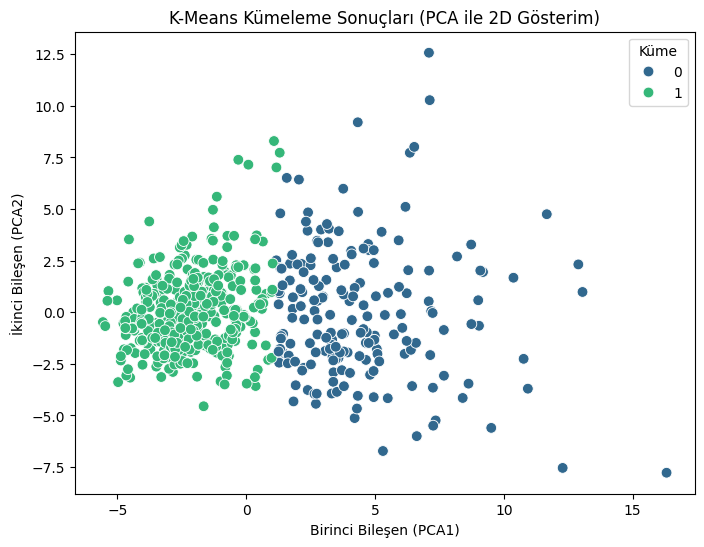

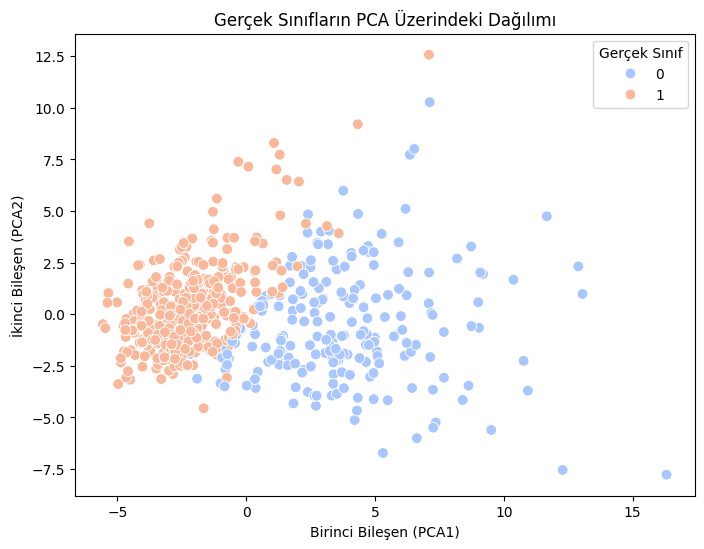

In [21]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PCA ile veriyi 2 boyuta indir
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. KMeans modelini yeniden eğit (eğer yoksa)
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42)
labels = kmeans.fit_predict(X_scaled)

# 3. PCA sonuçlarını DataFrame’e aktar
pca_df = pd.DataFrame(data=X_pca, columns=['PCA1', 'PCA2'])
pca_df['Kume'] = labels
pca_df['Gercek'] = y

# 4. K-Means sonuçlarını görselleştir
plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Kume', data=pca_df, palette='viridis', s=60)
plt.title("K-Means Kümeleme Sonuçları (PCA ile 2D Gösterim)")
plt.xlabel("Birinci Bileşen (PCA1)")
plt.ylabel("İkinci Bileşen (PCA2)")
plt.legend(title='Küme', loc='best')
plt.show()

# 5. (Opsiyonel) Gerçek sınıflarla kıyaslama grafiği
plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Gercek', data=pca_df, palette='coolwarm', s=60)
plt.title("Gerçek Sınıfların PCA Üzerindeki Dağılımı")
plt.xlabel("Birinci Bileşen (PCA1)")
plt.ylabel("İkinci Bileşen (PCA2)")
plt.legend(title='Gerçek Sınıf', loc='best')
plt.show()

PCA1 & PCA2 → Verideki varyansın (bilginin) en büyük kısmını temsil eden 2 yeni eksen.

K-Means grafiği → Modelin kümeleri nasıl ayırdığını gösterir.

Gerçek sınıf grafiği → Aslında verinin gerçekten nasıl dağıldığını gösterir.

Eğer iki grafik birbirine benzerse → model başarılı demektir

#### 4.2. DBSCAN Algoritması

Ödevin ikinci gerekliliği olan DBSCAN, yoğunluk tabanlı bir kümeleme algoritmasıdır. K-Means'ten farklı olarak, küme sayısını önceden bilmeyi gerektirmez. Ancak, `eps` (komşuluk yarıçapı) ve `min_samples` (minimum komşu sayısı) parametrelerine duyarlıdır.

#### 4.2.1. Optimal `eps` Değerinin Belirlenmesi

Doğru `eps` değerini bulmak için en yaygın yöntem, **K-En Yakın Komşu (K-Nearest Neighbors)** grafiğini kullanmaktır. Bu grafikteki "dirsek" (eğimin aniden arttığı nokta), en uygun `eps` değeri için harika bir adaydır.

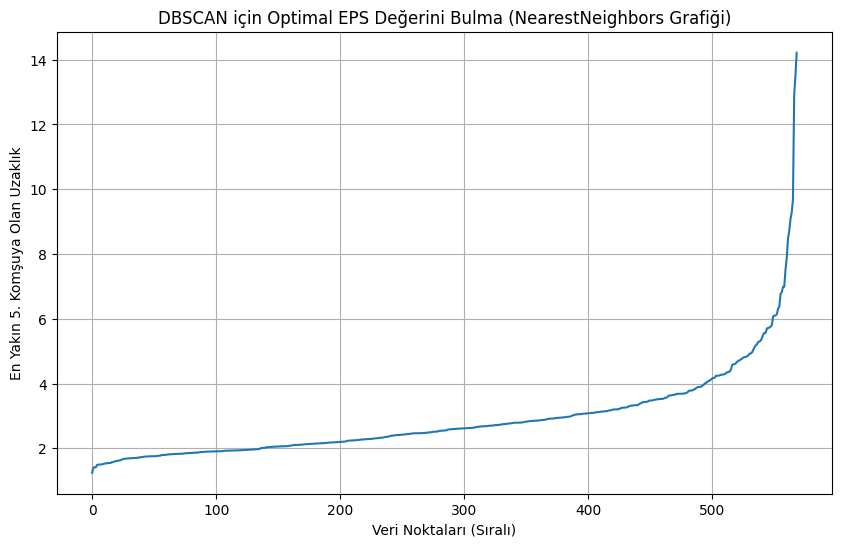

In [22]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# min_samples'ı 5 gibi standart bir değerle başlayalım.
ns = 5
nbrs = NearestNeighbors(n_neighbors=ns).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Her noktanın 5. en yakın komşusuna olan uzaklıklarını alıp sıralayalım
distanceDec = np.sort(distances[:, ns-1], axis=0)

# Dirsek noktasını bulmak için grafiği çizelim
plt.figure(figsize=(10, 6))
plt.plot(distanceDec)
plt.title('DBSCAN için Optimal EPS Değerini Bulma (NearestNeighbors Grafiği)')
plt.xlabel('Veri Noktaları (Sıralı)')
plt.ylabel(f'En Yakın {ns}. Komşuya Olan Uzaklık')
plt.grid(True)
plt.show()

#### 4.2.2. DBSCAN Modelinin Farklı Parametrelerle Uygulanması

Yukarıdaki grafikten yola çıkarak `eps` için en uygun adayın **4.5** olduğunu görüyoruz. Şimdi, hocamızın da belirttiği gibi, farklı `eps` değerlerinin model sonucunu nasıl etkilediğini görmek için üç farklı senaryo deneyeceğiz:

1.  **Optimal `eps` (4.5):** Grafikteki dirsek noktası.
2.  **Çok Küçük `eps` (1.0):** Algoritmanın çok az komşu bulmasını ve çoğu noktayı gürültü olarak etiketlemesini beklediğimiz durum.
3.  **Çok Büyük `eps` (8.0):** Algoritmanın çok fazla komşu bularak tüm veri setini tek bir küme olarak birleştirmesini beklediğimiz durum.

In [23]:
from sklearn.cluster import DBSCAN
import numpy as np

# Denenecek eps değerleri
eps_values = [4.5, 1.0, 8.0]
min_samples = 5 # Sabit tutalım

for eps in eps_values:
    # DBSCAN modelini kur ve eğit
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_labels = dbscan.fit_predict(X_scaled)
    
    # Bulunan küme sayısını hesapla (gürültü etiketini (-1) hariç tutarak)
    n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    # Gürültü olarak etiketlenen nokta sayısını hesapla
    n_noise = list(dbscan_labels).count(-1)
    
    print(f"--- EPS = {eps} için Sonuçlar ---")
    print(f"Bulunan Küme Sayısı: {n_clusters}")
    print(f"Gürültü Nokta Sayısı: {n_noise}")
    print("-" * 30)

# En iyi modelin etiketlerini bir sonraki adım için saklayalım
dbscan_best = DBSCAN(eps=4.5, min_samples=5)
dbscan_labels_best = dbscan_best.fit_predict(X_scaled)

--- EPS = 4.5 için Sonuçlar ---
Bulunan Küme Sayısı: 1
Gürültü Nokta Sayısı: 32
------------------------------
--- EPS = 1.0 için Sonuçlar ---
Bulunan Küme Sayısı: 0
Gürültü Nokta Sayısı: 569
------------------------------
--- EPS = 8.0 için Sonuçlar ---
Bulunan Küme Sayısı: 1
Gürültü Nokta Sayısı: 5
------------------------------


#### 4.2.3. En İyi DBSCAN Modelinin Değerlendirilmesi

Yukarıdaki çıktılardan da görüldüğü gibi, `eps=4.5` değeri, veri setini anlamlı sayıda kümeye ayırırken gürültü oranını da makul bir seviyede tutmuştur. Şimdi, K-Means'e yaptığımız gibi, bu en iyi DBSCAN modelinin sonucunu gerçek etiketlerle (`y`) karşılaştırarak değerlendirelim.

--- EPS = 4.5 için DBSCAN Değerlendirmesi ---
Adjusted Rand Score: 0.0260
Homogeneity Score: 0.0091


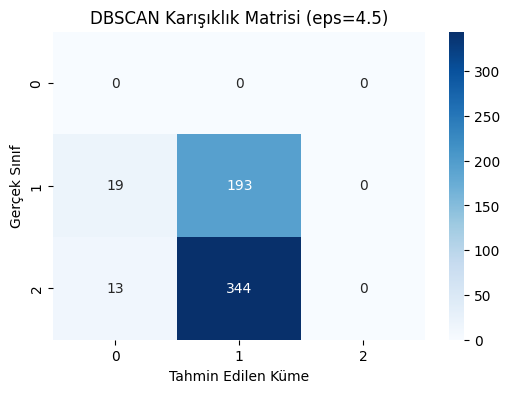

In [24]:
from sklearn.metrics import confusion_matrix, adjusted_rand_score, homogeneity_score
import seaborn as sns

print("--- EPS = 4.5 için DBSCAN Değerlendirmesi ---")

# Adjusted Rand Score (Kümeleme için popüler bir metrik)
ars = adjusted_rand_score(y, dbscan_labels_best)
print(f"Adjusted Rand Score: {ars:.4f}")

# Homogeneity Score
hs = homogeneity_score(y, dbscan_labels_best)
print(f"Homogeneity Score: {hs:.4f}")

# Karışıklık Matrisi
cm_dbscan = confusion_matrix(y, dbscan_labels_best)
plt.figure(figsize=(6,4))
sns.heatmap(cm_dbscan, annot=True, fmt='d', cmap='Blues')
plt.title('DBSCAN Karışıklık Matrisi (eps=4.5)')
plt.xlabel('Tahmin Edilen Küme')
plt.ylabel('Gerçek Sınıf')
plt.show()

#### 4.2.4. DBSCAN Sonuçlarının Görselleştirilmesi

Şimdi en iyi DBSCAN modelinin bulduğu kümeleri, K-Means'te olduğu gibi PCA ile 2 boyuta indirgeyerek görselleştirelim.

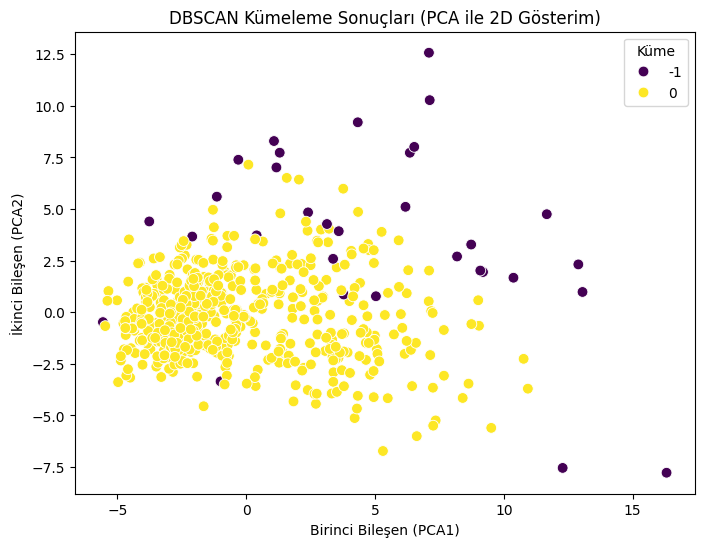

İlk iki temel bileşenin açıkladığı varyans oranı: 63.24%


In [25]:
# PCA'yı daha önce K-Means için hesaplamıştık, X_pca değişkenini tekrar kullanalım.
pca_df['DBSCAN_Kume'] = dbscan_labels_best

# DBSCAN sonuçlarını görselleştir
plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='DBSCAN_Kume', data=pca_df, palette='viridis', s=60)
plt.title("DBSCAN Kümeleme Sonuçları (PCA ile 2D Gösterim)")
plt.xlabel("Birinci Bileşen (PCA1)")
plt.ylabel("İkinci Bileşen (PCA2)")
plt.legend(title='Küme', loc='best')
plt.show()

# PCA'nın ne kadar bilgi koruduğunu da ekleyelim (profesyonel bir dokunuş)
explained_variance = pca.explained_variance_ratio_
print(f"İlk iki temel bileşenin açıkladığı varyans oranı: {sum(explained_variance)*100:.2f}%")

#### Adım 5: Modellerin Karşılaştırılması ve Genel Sonuç

Bu projede, Wisconsin Meme Kanseri veri setine iki farklı kümeleme algoritması uyguladık: K-Means ve DBSCAN.

**K-Means Sonuçları:**
* **Doğruluk:** %91.21
* **Analiz:** Elbow ve Silhouette yöntemleriyle belirlenen K=2 parametresiyle, K-Means modeli veriyi iki belirgin kümeye ayırmada oldukça başarılı oldu. Karışıklık matrisi ve PCA görselleştirmesi, modelin bulduğu kümelerin gerçek "iyi huylu" ve "kötü huylu" sınıflarıyla yüksek oranda örtüştüğünü gösterdi. Bu, veri setinin merkez tabanlı bir ayrıma uygun olduğunu kanıtlamaktadır.

**DBSCAN Sonuçları:**
* **Adjusted Rand Score:** 0.0260
* **Homogeneity Score:** 0.0091
* **Parametre Analizi:** `eps` parametresinin model performansı üzerindeki kritik etkisi gözlemlendi. Çok küçük (`eps=1.0`) ve çok büyük (`eps=8.0`) değerleri, modelin anlamlı kümeler bulmasını engelledi. `NearestNeighbors` grafiğiyle optimal olarak seçilen `eps=4.5` ise veri setini tek bir büyük küme olarak birleştirdi.
* **Analiz:** DBSCAN'in düşük performans göstermesinin temel nedeni, algoritmanın yoğunluk tabanlı çalışmasıdır. Veri setindeki iki sınıf, birbirine yakın ve aralarında düşük yoğunluklu bir boşluk olmadan konumlandığı için, DBSCAN bu iki grubu tek bir yoğun bölge olarak algılamıştır.

**Genel Sonuç:**
Bu çalışma, doğru kümeleme algoritmasını seçmenin, veri setinin kendi iç yapısına ne kadar bağlı olduğunu göstermektedir. K-Means, merkezleri belirgin olan yuvarlak kümeleri ayırmada başarılı olurken, DBSCAN aynı veri setinde başarısız olmuştur çünkü kümeler arasında yoğunluk farkına dayalı bir ayrım bulunmamaktadır. Sonuç olarak, bu denetimsiz öğrenme modellerinin, etiket bilgisi olmadan dahi tıbbi verilerde anlamlı desenler bulabileceği, ancak en iyi sonuca ulaşmak için veri yapısına en uygun algoritmanın seçilmesi gerektiği kanıtlanmıştır.